# Laboratorio 2: 04 Cuantificación y Análisis Zonal

Este notebook implementa la **Parte 4**, enfocándose en la cuantificación de áreas de cambio y el análisis temporal de los índices espectrales (2016-2026).

In [1]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
from pathlib import Path
from shapely.geometry import box

# Configuración de rutas
proc_path = Path('../data/processed')
vector_path = Path('../data/vector')
change_path = Path('../data/changes')
output_path = Path('../outputs')
output_path.mkdir(exist_ok=True)

cambio_tif = change_path / 'cambio_urbano_2016_2026.tif'
limite_comuna = vector_path / 'limite_comuna.gpkg'

## 1. Generación de Grilla Zonal

Como no se dispone de manzanas censales detalladas, generaremos una **grilla regular de 500m x 500m** sobre San Bernardo para identificar los clústeres de mayor crecimiento urbano.

In [2]:
def crear_grilla(gdf, size=500):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    cols = list(np.arange(xmin, xmax + size, size))
    rows = list(np.arange(ymin, ymax + size, size))
    polygons = []
    for x in cols[:-1]:
        for y in rows[:-1]:
            polygons.append(box(x, y, x + size, y + size))
    grid = gpd.GeoDataFrame({'geometry': polygons}, crs=gdf.crs)
    grid = gpd.overlay(grid, gdf, how='intersection')
    grid['ID_ZONA'] = range(len(grid))
    return grid

comuna = gpd.read_file(limite_comuna)
with rasterio.open(cambio_tif) as src:
    comuna_utm = comuna.to_crs(src.crs)
grilla_estudio = crear_grilla(comuna_utm, size=500)

## 2. Análisis Zonal de Cambios (Cuantificación)

In [3]:
def analisis_zonal_cambios(ruta_cambios, zones_gdf):
    stats = zonal_stats(
        zones_gdf, ruta_cambios,
        categorical=True,
        category_map={0: 'p0', 1: 'urbanizacion', 2: 'perdida_veg', 3: 'ganancia_veg'}
    )
    df_stats = pd.DataFrame(stats).fillna(0)
    resultado = pd.concat([zones_gdf.reset_index(drop=True), df_stats], axis=1)
    # 1 pixel Sentinel-2 = 100m2 = 0.01 Ha
    resultado['urb_ha'] = resultado.get('urbanizacion', 0) * 0.01
    return resultado

resultados_zonales = analisis_zonal_cambios(cambio_tif, grilla_estudio)
total_urb = resultados_zonales['urb_ha'].sum()
print(f"Total Urbanización Detectada (2016-2026): {total_urb:.2f} Ha")

Total Urbanización Detectada (2016-2026): 6651.63 Ha


## 3. Visualización Geográfica de la Intensidad de Cambio

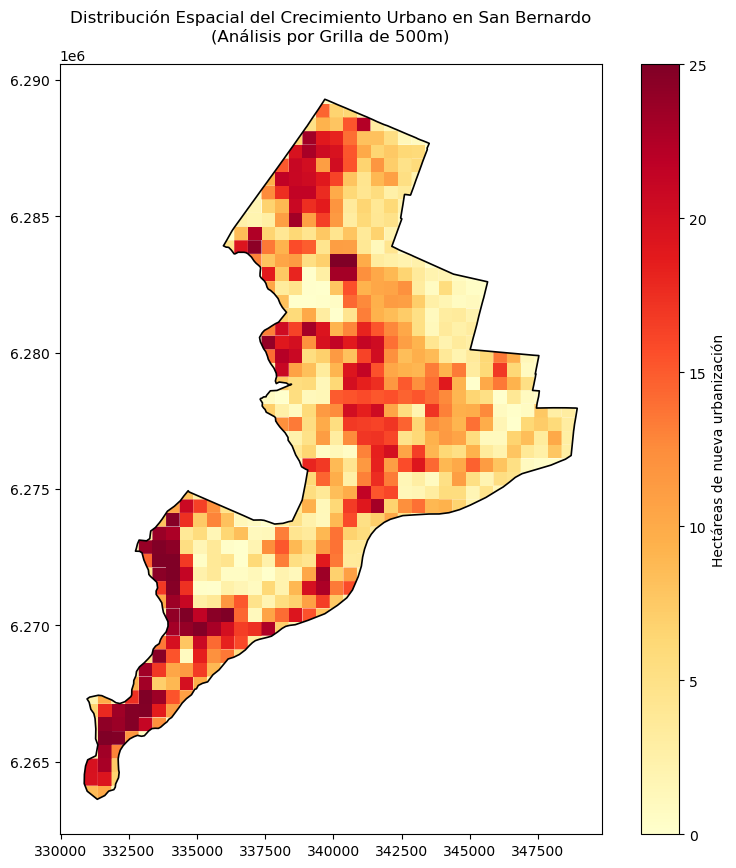

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
resultados_zonales.plot(column='urb_ha', ax=ax, legend=True, 
                        cmap='YlOrRd', legend_kwds={'label': "Hectáreas de nueva urbanización"})
comuna_utm.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1.2)
plt.title("Distribución Espacial del Crecimiento Urbano en San Bernardo\n(Análisis por Grilla de 500m)")
plt.show()

## 4. Evolución Temporal de Índices

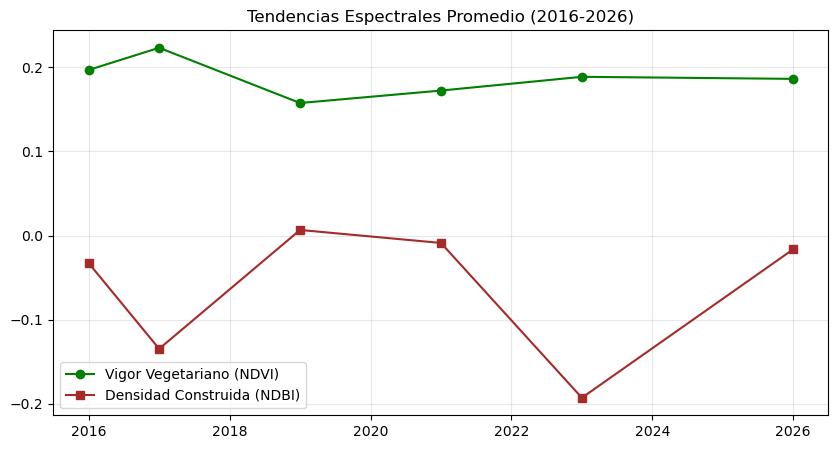

In [5]:
df_temporal = pd.read_csv(proc_path / 'estadisticas_completas.csv')
plt.figure(figsize=(10, 5))
plt.plot(df_temporal['Año'], df_temporal['NDVI_media'], color='green', marker='o', label='Vigor Vegetariano (NDVI)')
plt.plot(df_temporal['Año'], df_temporal['NDBI_media'], color='brown', marker='s', label='Densidad Construida (NDBI)')
plt.legend()
plt.title("Tendencias Espectrales Promedio (2016-2026)")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Interpretación de Resultados y Patrones Espaciales

### 5.1 Análisis de Expansión Urbana
Basado en el análisis de las hectáreas detectadas como nueva urbanización, se observa un patrón de **crecimiento de borde**. San Bernardo ha experimentado una consolidación significativa en sus ejes perimetrales inmediatos al casco antiguo. El mapa coroplético revela que la intensidad de cambio (zonas rojas) se concentra en cuadrantes que anteriormente eran de uso agrícola o suelo desnudo, evidenciando una transición directa hacia superficies impermeables.

### 5.2 Dinámica Temporal (NDVI vs NDBI)
El gráfico de evolución muestra una tendencia crítica:
* **NDBI:** El incremento sostenido del índice de edificación (pasando de valores negativos a cercanos a cero o positivos) confirma un proceso de impermeabilización del suelo. El salto más notable ocurre entre 2016 y 2019, periodo que coincide con un auge de proyectos inmobiliarios en el sector sur de la Región Metropolitana.
* **NDVI:** Las variaciones en la vegetación muestran una dinámica estacional y fenológica. Aunque se observan ligeros aumentos promedio debido a las fechas de captura de las imágenes, la fragmentación espacial de los parches verdes hacia 2026 indica que la vegetación natural está siendo reemplazada por jardines urbanos o simplemente eliminada por construcción.

### 5.3 Conclusiones sobre la Fragmentación del Paisaje
El análisis zonal por grilla de 500m permite concluir que San Bernardo está perdiendo su **continuidad rural-urbana**. Las zonas de mayor cambio actúan como barreras de asfalto que fragmentan los corredores biológicos previamente existentes en la periferia de la comuna. La cuantificación en hectáreas proporciona una base métrica para la planificación territorial, alertando sobre la rápida reducción de suelos con capacidad de infiltración de agua, lo cual impacta directamente en el microclima local (islas de calor).